# Failure under harmful fine-tuning

**Paper Section 5 (Results: harmful fine-tuning) and Appendix C.** The latent attack in `03` is one
intervention; a parameter-space intervention is another. We fine-tune base and dissociated on harmful
instruction-response pairs and watch judged compliance climb, step by step, on two attack
distributions: **in-distribution** (held-out rows of the LLM-LAT source used to build the harmful
pole) and **out-of-distribution** (PKU-SafeRLHF unsafe responses, never seen by any construction
stage). If the dissociated model already sits closer to a harmful solution, it should give way sooner
on both.

**Produces**: `harmful_sft_compliance_curves.pdf` (Results figure, onset view),
`harmful_sft_full_range.pdf` (Appendix C), the $t_{0.8}$ onset and step-0 compliance table
(Appendix C, quoted in the Results prose), the in-distribution onset row of the paper's Table 1,
and `harmful_reference_curves.pdf` (Appendix C). All twelve (arch, variant, data) cells carry three seeds (0, 1, 2); the curves show the
across-seed mean with a min-max envelope, and the onset is reported as mean +/- sd over seeds.

## Parameter-space intervention

Fine-tuning takes gradient steps on the harmful supervised loss,

$$\theta_{t+1}=\theta_t-\eta\,\nabla_\theta\,\mathcal{L}_{\mathrm{SFT}}(\theta_t;\mathcal{D}_{\mathrm{harm}}),$$

with constant $\eta=10^{-5}$, batch 4, for up to 150 steps. Every 5 steps we generate on 60 fixed
held-out HarmBench behaviors and judge with the HarmBench classifier; compliance is the judged-harmful
fraction. Because enough harmful training breaks any of these models, the statistic of interest is the
onset speed,

$$t_\tau=\min\{t:\ \mathrm{compliance}_t\ge\tau\},\qquad \tau=0.8,$$

resolved on the 5-step evaluation grid.

In [1]:
import warnings; warnings.simplefilter("ignore")
from nbtools import *          # paths, palette, loaders, savefig, lvs reuse
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
apply_style()

sft = load_harmful_sft()
print("seeds on disk:", sorted(sft["seed"].unique()))
archs = discover_arches("harmful_sft")
print("harmful-SFT runs on disk:", archs)
note = missing_note(archs, "harmful_sft")
if note: print(note)
DATA_LABEL = {"llm-lat": "in-dist (LLM-LAT)", "pku": "OOD (PKU)"}

seeds on disk: [np.int64(0), np.int64(1), np.int64(2)]
harmful-SFT runs on disk: ['gemma2-2b', 'llama3.2-3b', 'qwen2.5-3b']


### Compliance under harmful SFT

Rows: attack data in-distribution (top) and out-of-distribution (bottom). The dotted line marks
$\tau=0.8$. All the information is in the onset, so the camera-ready panel shows the first 50 steps;
every curve stays on its plateau through step 150 (the onset table below is computed on the full
range, and the full-range view follows as a separate appendix figure). The line is the across-seed
mean (3 seeds) and the shaded band the across-seed min-max envelope.

saved notebooks/figures/harmful_sft_compliance_curves.pdf


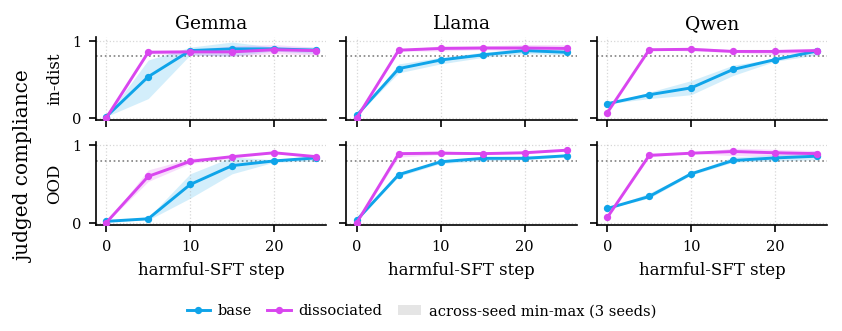

saved notebooks/figures/harmful_sft_full_range.pdf


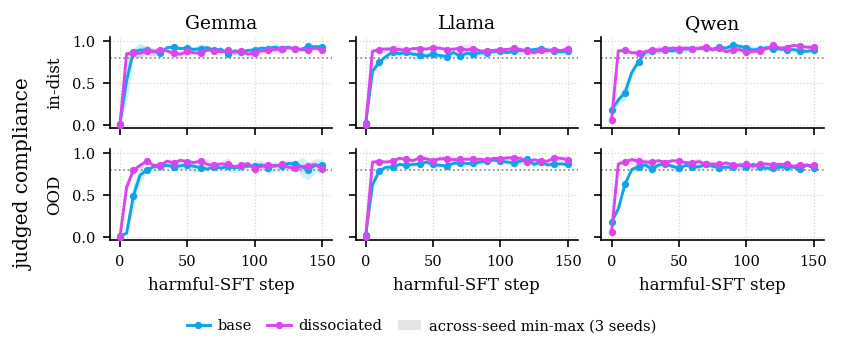

In [2]:
from matplotlib.patches import Patch

def plot_sft(xmax, name, height):
    fig, axes = plt.subplots(len(datas), len(archs), figsize=(FULL_W, height),
                             squeeze=False, sharex=True, sharey=True, layout="constrained")
    for i, data in enumerate(datas):
        for j, arch in enumerate(archs):
            ax = axes[i][j]
            for variant in ("base", "dissociated"):
                s = sft[(sft.arch == arch) & (sft.variant == variant) & (sft.data == data)]
                s = s[s.step <= xmax]
                g = s.groupby("step")["compliance"]
                steps = sorted(s["step"].unique())
                mean = g.mean().reindex(steps).to_numpy()
                lo = g.min().reindex(steps).to_numpy(); hi = g.max().reindex(steps).to_numpy()
                ax.fill_between(steps, lo, hi, color=PALETTE[variant], alpha=0.18, lw=0, zorder=1)
                ax.plot(steps, mean, "-o", color=PALETTE[variant], ms=2.5,
                        markevery=1 if xmax <= 60 else 2, label=variant, zorder=3)
            ax.axhline(0.8, color="0.5", lw=0.8, ls=":", zorder=0)
            ax.set_ylim(-0.03, 1.05)
            if i == 0:
                ax.set_title(ARCH_SHORT[arch])
            if i == len(datas) - 1:
                ax.set_xlabel("harmful-SFT step")
        axes[i][0].set_ylabel({"llm-lat": "in-dist", "pku": "OOD"}[datas[i]])
    fig.supylabel("judged compliance")
    h, l = axes[0][0].get_legend_handles_labels()
    h += [Patch(facecolor="0.6", alpha=0.25)]
    l += ["across-seed min-max (3 seeds)"]
    fig.legend(h, l, loc="outside lower center", ncol=3)
    savefig(fig, name); plt.show()

N_EVAL = 60
datas = ["llm-lat", "pku"]
plot_sft(25, "harmful_sft_compliance_curves", 2.1)    # onset view (paper Section 5)
plot_sft(150, "harmful_sft_full_range", 2.2)           # full range (paper Appendix C)

### Onset speed

$t_{0.8}$ per architecture and attack distribution, next to the compliance each model starts from at
step 0 (identical across seeds, since step 0 is the unmodified model on a fixed eval set). The
dissociated model starts at least as safe and unlocks first; over the three seeds it reaches the
threshold strictly earlier than its base in every seed-paired run.

In [3]:
import pandas as pd
rows = []
for (arch, variant, data, seed), sub in sft.groupby(["arch", "variant", "data", "seed"], observed=True):
    hit = sub[sub["compliance"] >= 0.8]["step"]
    rows.append({"arch": arch, "variant": str(variant), "data": data, "seed": seed,
                 "t": float(hit.min()) if len(hit) else float("nan")})
per_seed = pd.DataFrame(rows)
nseed = int(per_seed["seed"].nunique())
if nseed > 1:
    g = per_seed.groupby(["arch", "data", "variant"])["t"]
    tt = (g.mean().round(1).astype(str) + " +/- " + g.std().round(1).astype(str)).unstack("variant")
    print(f"t_0.8 mean +/- sd over {nseed} seeds (steps); grid resolution 5 steps")
else:
    tt = per_seed.pivot_table(index=["arch", "data"], columns="variant", values="t", observed=True)
    print("t_0.8 (steps), single seed (0); grid resolution 5 steps")
c0 = sft[sft.step == 0].groupby(["arch", "data", "variant"], observed=True)["compliance"].mean().round(3).unstack("variant")
display(pd.concat({"t_0.8": tt, "step-0 compliance": c0}, axis=1))

t_0.8 mean +/- sd over 3 seeds (steps); grid resolution 5 steps


t_0.8               step-0 compliance            
variant                      base   dissociated              base dissociated
arch        data                                                             
gemma2-2b   llm-lat  10.0 +/- 0.0   5.0 +/- 0.0             0.017       0.000
            pku      20.0 +/- 5.0  13.3 +/- 2.9             0.017       0.000
llama3.2-3b llm-lat  16.7 +/- 2.9   5.0 +/- 0.0             0.033       0.000
            pku      11.7 +/- 2.9   5.0 +/- 0.0             0.033       0.000
qwen2.5-3b  llm-lat  25.0 +/- 0.0   5.0 +/- 0.0             0.183       0.067
            pku      18.3 +/- 2.9   5.0 +/- 0.0             0.183       0.067

### Reference: the harmful pole during its own construction

Shown only to mark where an openly harmful model saturates under the same judge.

saved notebooks/figures/harmful_reference_curves.pdf


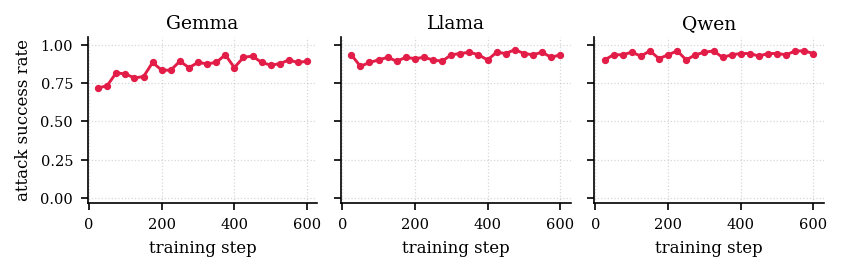

In [4]:
archs_h = discover_arches("harmful")
fig, axes = plt.subplots(1, len(archs_h), figsize=(FULL_W, 1.7),
                         squeeze=False, sharey=True, layout="constrained")
for j, arch in enumerate(archs_h):
    ref = load_harmful_reference(arch)
    ycol = "compliance" if ref.attrs.get("source") == "pipeline" else "asr"
    xcol = "step" if "step" in ref.columns else "global_step"
    ax = axes[0][j]
    ax.plot(ref[xcol], ref[ycol], "-o", color=PALETTE["harmful"], ms=2.5)
    ax.set_title(ARCH_SHORT[arch]); ax.set_xlabel("training step"); ax.set_ylim(-0.03, 1.05)
axes[0][0].set_ylabel("attack success rate")
savefig(fig, "harmful_reference_curves"); plt.show()

## What this shows

Both models can be fine-tuned into compliance, but the dissociated model gets there first. It reaches
80% judged compliance at step 5 in five of the six settings (Gemma OOD takes 15), while the bases need
10 to 25 steps, and it starts safer, with step-0 compliance of 0.00 to 0.07 against 0.02 to 0.18 for
the bases. The lead survives on PKU data that no construction stage ever used, so it is not a
re-activation of the training distribution: the door is a property of the representation. A small
amount of harmful fine-tuning surfaces what the dissociated model was already carrying, the
parameter-space echo of the latent vulnerability measured in `03`.